In [1]:
# Upgrade pip, setuptools, and wheel
!pip install --upgrade pip setuptools wheel --quiet

# Install essential system libraries for building packages
!apt-get update -qq
!apt-get install -y build-essential libffi-dev python3-dev python3-pip --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 45.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 37.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists...
Building dependency tree...
Reading state information...
build-essential is already the newest version (12.9ubuntu3).
libffi-dev is already the newest version (3.4.2-4).
libffi-dev set to manually installed.
The following additional packages will be installed:
  javascript-common libjs-sphinxdoc libjs-underscore python3-pkg-resources
  python3-setuptools python3-wheel python3.10-dev
Suggested p

In [2]:
!pip install datasets
!pip install transformers
!pip install accelerate
!pip install evaluate
!pip install mlflow
!pip install emoji --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 34.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 58.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 54.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 753.9/753.9 kB 29.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11/11 [mlflow]


In [3]:
import mlflow
import mlflow.pytorch
from datasets import load_dataset, concatenate_datasets, Dataset, ClassLabel
import pandas as pd
import numpy as np
import random
from collections import Counter
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix, classification_report,
    precision_recall_fscore_support
)
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    Trainer, TrainingArguments, DataCollatorWithPadding,
    EarlyStoppingCallback
)
import matplotlib.pyplot as plt
import seaborn as sns
from torch import nn
import torch
import os
import json
import warnings
warnings.filterwarnings('ignore')

device = "cuda" if torch.cuda.is_available() else "cpu"


# Data Loading

In [4]:
dataset_A = load_dataset("Shushant/NepaliSentiment")
dataset_B = load_dataset("Ajhesh7/nepali_sentiment_dataset")

A_merged = concatenate_datasets([dataset_A["train"], dataset_A["test"]])
B_merged = concatenate_datasets([dataset_B["train"], dataset_B["validation"], dataset_B["test"]])

A_clean = A_merged.filter(lambda ex: ex["label"] in ["0","1","2"])
A_clean = A_clean.map(lambda ex: {"label": int(ex["label"])})

B_clean = B_merged.remove_columns(["Unnamed: 0"]).rename_column("Sentences","text").rename_column("Sentiment","label")
B_clean = B_clean.map(lambda ex: {"label": int(ex["label"])})

dataset_merged = concatenate_datasets([A_clean, B_clean])
print(f" Total rows loaded: {dataset_merged.num_rows}")

 Loading datasets...


train.csv: 0.00B [00:00, ?B/s]

test.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/6000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1996 [00:00<?, ? examples/s]

...

Generating test split:   0%|          | 0/7158 [00:00<?, ? examples/s]

Filter:   0%|          | 0/7996 [00:00<?, ? examples/s]

Map:   0%|          | 0/7985 [00:00<?, ? examples/s]

Map:   0%|          | 0/35789 [00:00<?, ? examples/s]

 Total rows loaded: 43774


# Data preprocessing

In [5]:
def normalize_text(t):
    s = (t or "").strip()
    s = s.replace("\n", " ")
    s = " ".join(s.split())
    return s if len(s) > 5 else None


df = dataset_merged.to_pandas()
df['text'] = df['text'].astype(str).apply(normalize_text)
df = df.dropna(subset=['text', 'label'])
df = df.drop_duplicates(subset=['text'], keep='first').reset_index(drop=True)
print(f"After preprocessing and removing duplicates: {len(df)}")

#

After preprocessing and removing duplicates: 41574


# class imbalance analysis

In [6]:


class_counts = df['label'].value_counts().sort_index()
label_names = {0: "Negative", 1: "Neutral", 2: "Positive"}

print("\nOriginal Class Distribution:")
for label, count in class_counts.items():
    pct = (count / len(df)) * 100
    print(f"  {label_names[label]:10s}: {count:6,} ({pct:5.2f}%)")

max_class = class_counts.max()
min_class = class_counts.min()
imbalance_ratio = max_class / min_class
print(f"Imbalance Ratio: {imbalance_ratio:.2f}:1")


Original Class Distribution:
  Negative  : 16,278 (39.15%)
  Neutral   :  8,092 (19.46%)
  Positive  : 17,204 (41.38%)
Imbalance Ratio: 2.13:1


# Imbalance handling and anti overfitting
* Oversampling 60%
* augmentation 15%
* regularization
* early stopping with patience=1
* freez first 4 layers
* dropout 0.3
* weight decay 0.03

In [7]:
# Oversampling

target_count = int(max_class * 0.6)

balanced_dfs = []
for label in sorted(df['label'].unique()):
    class_df = df[df['label'] == label]
    count = len(class_df)

    if count < target_count:
        n_samples = target_count - count
        oversampled = class_df.sample(n=n_samples, replace=True, random_state=42)
        balanced_dfs.append(pd.concat([class_df, oversampled]))
        print(f"  {label_names[label]:10s}: {count:6,} → {target_count:6,} (+{n_samples:5,})")
    else:
        balanced_dfs.append(class_df)
        print(f"  {label_names[label]:10s}: {count:6,} (no change)")

df_balanced = pd.concat(balanced_dfs, ignore_index=True)
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)


  Negative  : 16,278 (no change)
  Neutral   :  8,092 → 10,322 (+2,230)
  Positive  : 17,204 (no change)


In [8]:
# Augmentation

def augment_text(text, aug_type='swap'):
    words = text.split()
    if len(words) < 3:
        return text

    if aug_type == 'swap' and len(words) >= 4:
        idx1, idx2 = random.sample(range(len(words)), 2)
        words[idx1], words[idx2] = words[idx2], words[idx1]
    elif aug_type == 'delete':
        words = [w for w in words if random.random() > 0.10]
        if len(words) < 2:
            words = text.split()

    return ' '.join(words)

augmented_dfs = [df_balanced]
aug_threshold = int(max_class * 0.65)

In [9]:
for label in sorted(df_balanced['label'].unique()):
    class_df = df_balanced[df_balanced['label'] == label]
    current_count = len(class_df)

    if current_count < aug_threshold:
        n_augment = min(aug_threshold - current_count, int(current_count * 0.15))  # REDUCED to 15%

        augmented_samples = []
        samples_to_augment = class_df.sample(n=n_augment, random_state=42)

        for idx, row in samples_to_augment.iterrows():
            aug_type = random.choice(['swap', 'delete'])
            augmented_text = augment_text(row['text'], aug_type)
            augmented_samples.append({'text': augmented_text, 'label': label})

        if augmented_samples:
            aug_df = pd.DataFrame(augmented_samples)
            augmented_dfs.append(aug_df)
            print(f"  {label_names[label]:10s}: {current_count:6,} → {current_count + len(aug_df):6,} (+{len(aug_df):5,})")
    else:
        print(f"  {label_names[label]:10s}: {current_count:6,} (no augmentation)")

df_final = pd.concat(augmented_dfs, ignore_index=True)
df_final = df_final.sample(frac=1, random_state=42).reset_index(drop=True)


  Negative  : 16,278 (no augmentation)
  Neutral   : 10,322 → 11,182 (+  860)
  Positive  : 17,204 (no augmentation)


# dataset splitting

In [10]:
dataset_clean = Dataset.from_pandas(df_final[['text', 'label']])
dataset_clean = dataset_clean.cast_column("label", ClassLabel(names=["Negative","Neutral","Positive"]))
dataset_clean = dataset_clean.rename_column("label", "labels")
dataset_clean = dataset_clean.shuffle(seed=42)

train_temp = dataset_clean.train_test_split(test_size=0.2, seed=42, stratify_by_column="labels")
val_test = train_temp['test'].train_test_split(test_size=0.5, seed=42, stratify_by_column="labels")

train_set = train_temp['train']
val_set   = val_test['train']
test_set  = val_test['test']

print(f"  Total: {len(dataset_clean):,}")
print(f"  Train: {len(train_set):,} | Val: {len(val_set):,} | Test: {len(test_set):,}")


Casting the dataset:   0%|          | 0/44664 [00:00<?, ? examples/s]

  Total: 44,664
  Train: 35,731 | Val: 4,466 | Test: 4,467


In [11]:
model_name = "Shushant/nepaliBERT"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        max_length=256,
        padding=False,
        add_special_tokens=True
    )

print("\n Tokenizing datasets...")
tokenized_train = train_set.map(tokenize_function, batched=True, batch_size=1000, remove_columns=["text"])
tokenized_val   = val_set.map(tokenize_function, batched=True, batch_size=1000, remove_columns=["text"])
tokenized_test  = test_set.map(tokenize_function, batched=True, batch_size=1000, remove_columns=["text"])

tokenized_train.set_format(type="torch", columns=["input_ids","attention_mask","labels"])
tokenized_val.set_format(type="torch", columns=["input_ids","attention_mask","labels"])
tokenized_test.set_format(type="torch", columns=["input_ids","attention_mask","labels"])

config.json:   0%|          | 0.00/589 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]


 Tokenizing datasets...


Map:   0%|          | 0/35731 [00:00<?, ? examples/s]

Map:   0%|          | 0/4466 [00:00<?, ? examples/s]

Map:   0%|          | 0/4467 [00:00<?, ? examples/s]

In [12]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_name, num_labels=3,
    id2label={0:"Negative",1:"Neutral",2:"Positive"},
    label2id={"Negative":0,"Neutral":1,"Positive":2}
)

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at Shushant/nepaliBERT and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [13]:
# freezing layers
for param in model.bert.embeddings.parameters():
    param.requires_grad = False
for i in range(4):
    for param in model.bert.encoder.layer[i].parameters():
        param.requires_grad = False

In [14]:


trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Trainable parameters: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)")


Trainable parameters: 57,295,875 / 109,484,547 (52.3%)


# Class weights

In [15]:
y_train = np.array(train_set["labels"])
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = torch.tensor(class_weights, dtype=torch.float).to("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nClass weights: Neg={class_weights[0]:.4f}, Neu={class_weights[1]:.4f}, Pos={class_weights[2]:.4f}")


model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]


Class weights: Neg=0.9146, Neu=1.3314, Pos=0.8654


# Custom trainer

In [16]:
class RegTrainer(Trainer):
    """Trainer with stronger regularization"""
    def compute_loss(self, model, inputs, return_outputs=False,num_items_in_batch=None):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits

        # Weighted CE with STRONGER label smoothing
        loss_fct = nn.CrossEntropyLoss(
            weight=class_weights,
            label_smoothing=0.15  # Increased from 0.1
        )
        loss = loss_fct(logits.view(-1, 3), labels.view(-1))

        return (loss, outputs) if return_outputs else loss

In [17]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)


In [18]:
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    preds = np.argmax(predictions, axis=1)

    accuracy = accuracy_score(labels, preds)
    f1_macro = f1_score(labels, preds, average="macro")
    f1_weighted = f1_score(labels, preds, average="weighted")

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average=None, zero_division=0
    )

    return {
        "accuracy": accuracy,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted,
        "f1_negative": f1[0],
        "f1_neutral": f1[1],
        "f1_positive": f1[2],
    }

In [19]:
training_args = TrainingArguments(
    output_dir="./nepali-bert-regularized",
    num_train_epochs=6,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,

    learning_rate=1.5e-5,


    weight_decay=0.03,

    warmup_ratio=0.1,
    lr_scheduler_type="cosine",


    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,

    logging_steps=500,
    fp16=True,

    max_grad_norm=1.0,

    dataloader_num_workers=2,
    seed=42,
    report_to="none"
)

In [20]:
trainer = RegTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
    data_collator=data_collator,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=1)]  # VERY aggressive
)

In [21]:
!pip install --quiet mlflow dagshub


# Dagshub and mlflow traking

In [22]:
import mlflow
import dagshub

# Initialize DagsHub MLflow tracking
dagshub.init(
    repo_owner="arsapkota500",
    repo_name="nepali-sentiment-bert",
    mlflow=True
)

mlflow.set_tracking_uri("https://dagshub.com/arsapkota500/nepali-sentiment-bert.mlflow")
mlflow.set_experiment("nepaliBert-Sentiment-classification")

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=a03b3ee3-1a46-4a1c-b47d-500f5f1c78ea&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=156e368d0eacdf3c476e7fcac32736810919e79305124e1697487597523e85d4




Accessing as arsapkota500

Initialized MLflow to track repo "arsapkota500/nepali-sentiment-bert"

Repository arsapkota500/nepali-sentiment-bert initialized!

<Experiment: artifact_location='mlflow-artifacts:/76a202cd06ba4f68853e6ba7ff1bc842', creation_time=1763802125099, experiment_id='2', last_update_time=1763802125099, lifecycle_stage='active', name='nepaliBert-Sentiment-classification', tags={}>

In [23]:
import mlflow
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

# Ensure any previous MLflow run is ended before starting a new one
if mlflow.active_run():
    mlflow.end_run()

# Start MLflow run
with mlflow.start_run(run_name="nepali-bert-42k-regu"):

    # ------------------------ Train ------------------------
    trainer.train()

    # ------------------------ Evaluate ------------------------
    metrics = trainer.evaluate()
    mlflow.log_metrics(metrics)

    # ------------------------ Test predictions ------------------------
    test_results = trainer.predict(tokenized_test)
    y_true = test_results.label_ids
    y_pred = np.argmax(test_results.predictions, axis=1)

    # Classification report
    report = classification_report(y_true, y_pred, target_names=["Negative","Neutral","Positive"], digits=4, output_dict=True)
    mlflow.log_dict(report, "classification_report.json")  # log report as JSON

    # ------------------------ Confusion Matrix ------------------------
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap="Blues",
                xticklabels=["Neg","Neu","Pos"], yticklabels=["Neg","Neu","Pos"])
    plt.title("Confusion Matrix")
    plt.ylabel("True")
    plt.xlabel("Predicted")
    plt.savefig("confusion_matrix.png")      # save locally
    mlflow.log_artifact("confusion_matrix.png")  # log to MLflow
    plt.close()

    # ------------------------ Save model locally ------------------------
    trainer.save_model("./nepali-sentiment-bert-best-regu")
    tokenizer.save_pretrained("./nepali-sentiment-bert-best-regu")

    # ------------------------ Log model as MLflow artifact ------------------------
    mlflow.log_artifacts("./nepali-sentiment-bert-best-regu", artifact_path="nepali-bert-best-regu")

    print(" Training, evaluation, graphs, and model logging complete!")



Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted,F1 Negative,F1 Neutral,F1 Positive
1,0.876400,0.865922,0.685401,0.676430,0.685916,0.731265,0.597681,0.700345
2,0.795300,0.821025,0.726601,0.718802,0.726908,0.756740,0.652863,0.746802
3,0.723900,0.822254,0.742275,0.735576,0.741546,0.765808,0.686664,0.754255
4,0.660400,0.830131,0.740484,0.736837,0.741910,0.758665,0.695866,0.755981
5,0.609900,0.833932,0.752351,0.748349,0.752668,0.772965,0.712544,0.759539
6,0.588300,0.840499,0.749888,0.746002,0.750438,0.771411,0.709208,0.757386


 Training, evaluation, graphs, and model logging complete!
🏃 View run nepali-bert-42k-regu at: https://dagshub.com/arsapkota500/nepali-sentiment-bert.mlflow/#/experiments/2/runs/cfc25063657f41ff8e8a92d4933acffa
🧪 View experiment at: https://dagshub.com/arsapkota500/nepali-sentiment-bert.mlflow/#/experiments/2


# Tracking and mlflow tracking

In [ ]:
# import mlflow.onnx
# import onnx

# onnx_model_path = "nepali-sentiment-bert-regu.onnx"
# onnx_model = onnx.load(onnx_model_path)

# # Try to log as an MLflow ONNX model (this might still fail if the endpoint is truly unsupported)
# # mlflow.onnx.log_model(onnx_model, "onnx_model")

# # As a workaround, log the .onnx file as a generic artifact
# mlflow.log_artifact(onnx_model_path)

# print("✅ ONNX model file logged as an artifact in MLflow")

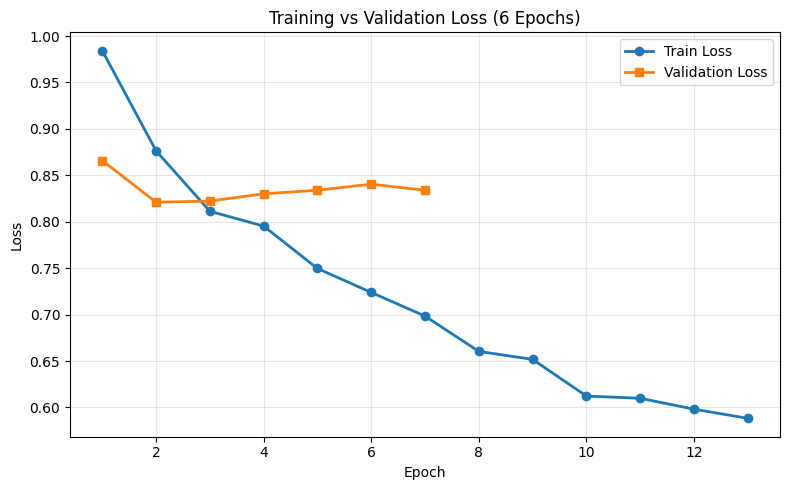

In [25]:

# Plot and log training & validation loss

history = trainer.state.log_history

# Extract losses per epoch
train_losses = [x['loss'] for x in history if 'loss' in x]
eval_losses  = [x['eval_loss'] for x in history if 'eval_loss' in x]

# Epochs (up to actual recorded values)
epochs = list(range(1, len(train_losses)+1))

plt.figure(figsize=(8,5))
plt.plot(epochs, train_losses, 'o-', label='Train Loss', linewidth=2)
plt.plot(epochs[:len(eval_losses)], eval_losses, 's-', label='Validation Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss (6 Epochs)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

# Save and log to MLflow
loss_plot_file = "training_validation_loss.png"
plt.savefig(loss_plot_file, dpi=300)
mlflow.log_artifact(loss_plot_file)
plt.show()
plt.close()


In [ ]:
# from huggingface_hub import HfApi, Repository
# from transformers import AutoTokenizer, AutoModelForSequenceClassification


# from huggingface_hub import login
# login(token="***********")  # replace with your HF token




# # Push PyTorch model and tokenizer
# model.push_to_hub("arsapkota/nepali-sentiment-bert-regu")
# tokenizer.push_to_hub("arsapkota/nepali-sentiment-bert-regu")

# print("Model uploaded to Hugging Face Hub")


In [26]:
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_curve, f1_score, precision_score, recall_score
from tabulate import tabulate

In [41]:
acc = np.mean(y_true == y_pred)
f1_macro = f1_score(y_true, y_pred, average='macro')
f1_weighted = f1_score(y_true, y_pred, average='weighted')
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')

In [42]:
report = classification_report(y_true, y_pred, digits=4, output_dict=True)


In [43]:
# Console table
table_data = [
    ["Accuracy", f"{acc:.4f}"],
    ["F1 Macro", f"{f1_macro:.4f}"],
    ["F1 Weighted", f"{f1_weighted:.4f}"],
    ["Precision", f"{precision:.4f}"],
    ["Recall", f"{recall:.4f}"],
    ["Loss", f"{results.metrics.get('test_loss', 'N/A'):.4f}" if 'test_loss' in results.metrics else 'N/A']
]
print("\n📊 Metrics for Test Set")
print(tabulate(table_data, headers=["Metric", "Value"], tablefmt="fancy_grid"))



📊 Metrics for Test Set
╒═════════════╤═════════╕
│ Metric      │   Value │
╞═════════════╪═════════╡
│ Accuracy    │  0.7609 │
├─────────────┼─────────┤
│ F1 Macro    │  0.7567 │
├─────────────┼─────────┤
│ F1 Weighted │  0.7611 │
├─────────────┼─────────┤
│ Precision   │  0.7616 │
├─────────────┼─────────┤
│ Recall      │  0.7609 │
├─────────────┼─────────┤
│ Loss        │  0.81   │
╘═════════════╧═════════╛


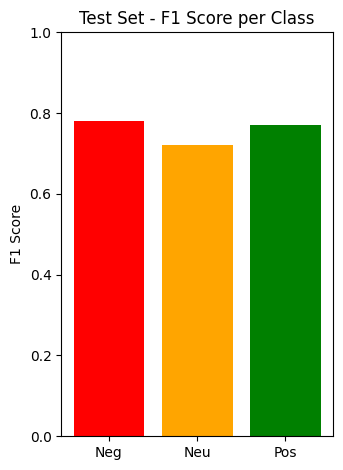

In [33]:
# F1 score per class
f1_per_class = [report[str(i)]["f1-score"] for i in range(3)]
plt.subplot(1,2,2)
plt.bar(["Neg","Neu","Pos"], f1_per_class, color=['red','orange','green'])
plt.ylim(0,1)
plt.title("Test Set - F1 Score per Class")
plt.ylabel("F1 Score")

plt.tight_layout()
plt.show()

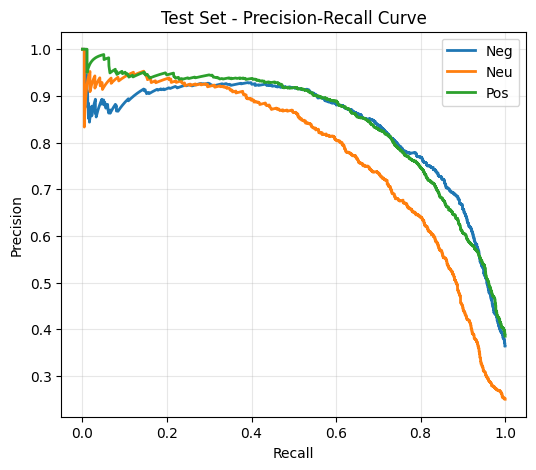

In [34]:
plt.figure(figsize=(6,5))
for i, label in enumerate(["Neg","Neu","Pos"]):
    precision_vals, recall_vals, _ = precision_recall_curve((y_true==i).astype(int), y_scores[:,i])
    plt.plot(recall_vals, precision_vals, lw=2, label=f"{label}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Test Set - Precision-Recall Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Passed the TEST and VALIDATION SET in model and generate COnfusion Matrix

Map:   0%|          | 0/4466 [00:00<?, ? examples/s]


Validation Set Confusion Matrix:
[[1258  159  211]
 [ 134  818  166]
 [ 235  201 1284]]

Classification Report:
              precision    recall  f1-score   support

         Neg     0.7732    0.7727    0.7730      1628
         Neu     0.6944    0.7317    0.7125      1118
         Pos     0.7730    0.7465    0.7595      1720

    accuracy                         0.7524      4466
   macro avg     0.7469    0.7503    0.7483      4466
weighted avg     0.7534    0.7524    0.7527      4466



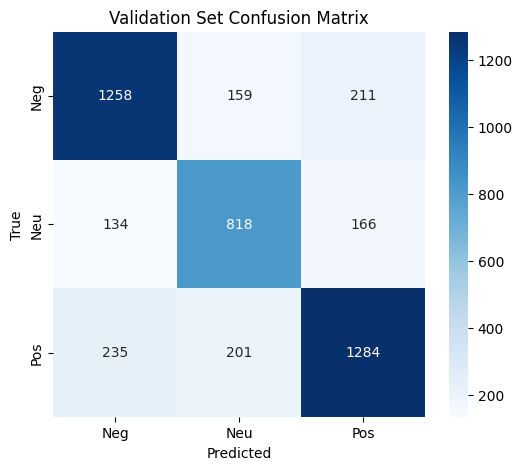

In [46]:
# Tokenize validation set
val_tokenized = val_set.map(
    lambda examples: tokenizer(examples["text"],
                               truncation=True,
                               padding=False,
                               max_length=256),
    batched=True
)

# Set format for PyTorch
val_tokenized.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

# Get predictions on validation set
val_results = trainer.predict(val_tokenized)
y_true = val_results.label_ids
y_pred = np.argmax(val_results.predictions, axis=1)

# Compute confusion matrix
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

labels = ["Neg", "Neu", "Pos"]
cm = confusion_matrix(y_true, y_pred)

# Print confusion matrix in console
print("\nValidation Set Confusion Matrix:")
print(cm)

# Print classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=labels, digits=4))

# Plot confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.title("Validation Set Confusion Matrix")
plt.ylabel("True")
plt.xlabel("Predicted")
plt.show()


Map:   0%|          | 0/4467 [00:00<?, ? examples/s]


Test Set Confusion Matrix:
[[1276  152  200]
 [ 136  820  162]
 [ 231  187 1303]]

Classification Report:
              precision    recall  f1-score   support

         Neg     0.7766    0.7838    0.7802      1628
         Neu     0.7075    0.7335    0.7202      1118
         Pos     0.7826    0.7571    0.7696      1721

    accuracy                         0.7609      4467
   macro avg     0.7556    0.7581    0.7567      4467
weighted avg     0.7616    0.7609    0.7611      4467



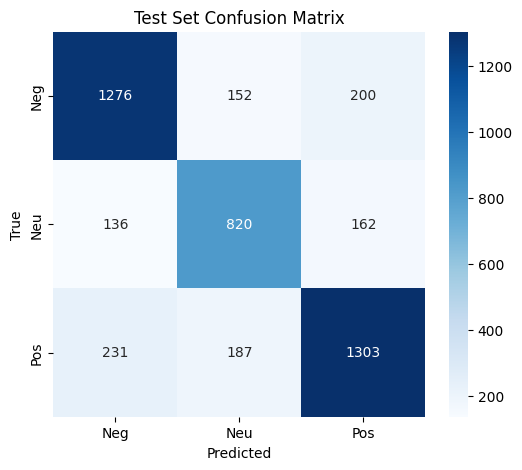

In [47]:
# Tokenize test set
test_tokenized = test_set.map(
    lambda examples: tokenizer(examples["text"],
                               truncation=True,
                               padding=False,
                               max_length=256),
    batched=True
)

# Set format for PyTorch
test_tokenized.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

# Get predictions on test set
test_results = trainer.predict(test_tokenized)
y_true_test = test_results.label_ids
y_pred_test = np.argmax(test_results.predictions, axis=1)

# Compute confusion matrix
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

labels = ["Neg", "Neu", "Pos"]
cm_test = confusion_matrix(y_true_test, y_pred_test)

# Print confusion matrix in console
print("\nTest Set Confusion Matrix:")
print(cm_test)

# Print classification report
print("\nClassification Report:")
print(classification_report(y_true_test, y_pred_test, target_names=labels, digits=4))

# Plot confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm_test, annot=True, fmt='d', cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.title("Test Set Confusion Matrix")
plt.ylabel("True")
plt.xlabel("Predicted")
plt.show()
